# The Enron email corpus: a first look

**Data Mining Lab, Summer 2026 (Task 1 report)**

Enron was a large US energy and commodities trading company based in Houston.
Through the 1990s it grew into one of the biggest firms in the country. In late
2001 it collapsed in an accounting-fraud scandal and filed for bankruptcy, at
the time one of the largest bankruptcies in US history.

The emails survived because of that collapse. While the Federal Energy
Regulatory Commission (FERC) investigated Enron's role in the 2000-2001
California electricity crisis, it placed the company's internal mailboxes into
the public record. They were never anonymised, so they still carry real names
and real business. Carnegie Mellon University hosts a cleaned copy, and that is
the version used here.

* Dataset home: https://www.cs.cmu.edu/~enron/
* Exact archive used: `enron_mail_20150507.tar.gz` (~423 MB), mirrored as a
  release asset on this repository.

This report describes what is in the corpus before any modelling: how big it
is, what each record looks like, how the numbers are distributed, and one
closer look at the mail people threw away. It reads top to bottom; each plot is
followed by what it shows, and the findings are collected at the end.

## The data: one file is one email

Every message is stored as a separate plain-text file in the RFC-822 format,
the long-standing standard for email. A block of headers (`From`, `To`,
`Subject`, `Date`, and so on) is followed by the message body. CMU kept each
employee's original folder tree, so a file's path also records whose mailbox it
came from and which folder they filed it under.

The cell below loads two prepared tables that an earlier pass extracted from the
raw mail and saved under `eda-2/cache/`. Working from these keeps the report fast
and reproducible without unpacking the 2.6 GB maildir. `df` has one row per
message with parsed and derived header fields; `body` holds a fixed sample of
message bodies used only where text length is needed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110


def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-2" / "cache" / "rich_header_features.parquet").exists():
            return base
    raise FileNotFoundError("could not locate eda-2/cache next to this notebook")


ROOT = find_root()
CACHE = ROOT / "eda-2" / "cache"
PLOTS = ROOT / "eda-3" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(CACHE / "rich_header_features.parquet")
body = pd.read_parquet(CACHE / "body_sample.parquet")

df["deleted"] = df["folder_group"].eq("deleted")
N = len(df)
print(f"{N:,} messages, {df['user'].nunique()} mailboxes, "
      f"{df['folder'].nunique():,} distinct folder names")
print(f"body sample: {len(body):,} messages")

517,401 messages, 150 mailboxes, 1,427 distinct folder names
body sample: 25,628 messages


### The variables

Most fields are read straight from the headers; a few are derived to make later
work easier. The table lists the ones used in this report.

In [2]:
variables = pd.DataFrame(
    [
        ("user", "mailbox owner the file was taken from (150 employees)"),
        ("folder", "original folder name the message was filed in"),
        ("folder_group", "folder collapsed into a broad type: inbox, sent, "
                          "deleted, calendar, discussion, topic/project"),
        ("date", "send time from the Date header, parsed to UTC"),
        ("date_plausible", "True if the date falls in the 1997-2002 Enron window"),
        ("from_addr", "sender email address"),
        ("from_domain", "domain part of the sender address"),
        ("is_internal_sender", "True if the sender domain is an enron.com domain"),
        ("recipient_count", "people on To + Cc + Bcc"),
        ("external_recipient_count", "recipients outside enron.com"),
        ("has_external_recipient", "True if at least one recipient is external"),
        ("is_mass_message", "True for very large recipient lists (bulk mail)"),
        ("subject", "raw Subject header"),
        ("subject_words", "word count of the subject"),
        ("file_size_kb", "size of the message file in kilobytes"),
        ("is_weekend", "True if sent on Saturday or Sunday"),
        ("has_in_reply_to", "True if an In-Reply-To header is present"),
        ("body_words", "words in the message body (body sample only)"),
    ],
    columns=["variable", "meaning"],
)
variables

,variable,meaning
0,user,mailbox owner the file was taken from (150 emp...
1,folder,original folder name the message was filed in
2,folder_group,"folder collapsed into a broad type: inbox, sen..."
3,date,"send time from the Date header, parsed to UTC"
4,date_plausible,True if the date falls in the 1997-2002 Enron ...
5,from_addr,sender email address
6,from_domain,domain part of the sender address
7,is_internal_sender,True if the sender domain is an enron.com domain
8,recipient_count,people on To + Cc + Bcc
9,external_recipient_count,recipients outside enron.com


## How much mail, and from whom

The corpus is not spread evenly across the 150 people. A handful of mailboxes
hold most of the mail, so any company-wide statement has to keep that imbalance
in mind.

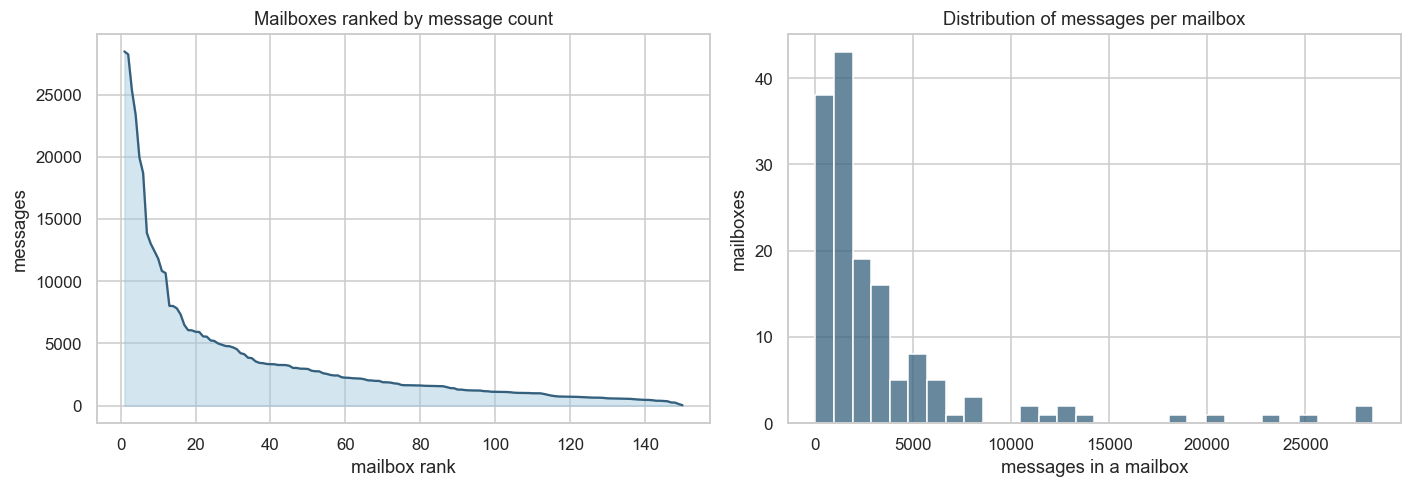

largest mailbox: kaminski-v with 28,465 messages
median mailbox: 1,652 messages
ten largest mailboxes hold 37.7% of all mail


In [3]:
per_user = df.groupby("user").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(range(1, len(per_user) + 1), per_user.values, color="#34607d")
axes[0].fill_between(range(1, len(per_user) + 1), per_user.values,
                     color="#9ec6dd", alpha=0.45)
axes[0].set(title="Mailboxes ranked by message count",
            xlabel="mailbox rank", ylabel="messages")

sns.histplot(per_user.values, bins=30, ax=axes[1], color="#34607d")
axes[1].set(title="Distribution of messages per mailbox",
            xlabel="messages in a mailbox", ylabel="mailboxes")
fig.tight_layout()
fig.savefig(PLOTS / "mailbox_sizes.png", bbox_inches="tight")
plt.show()

top10 = per_user.head(10).sum() / N
print(f"largest mailbox: {per_user.index[0]} with {per_user.iloc[0]:,} messages")
print(f"median mailbox: {per_user.median():,.0f} messages")
print(f"ten largest mailboxes hold {top10:.1%} of all mail")

The largest single mailbox (`kaminski-v`) holds 28,465 messages while the
median mailbox holds about 1,650. The ten biggest mailboxes together account
for roughly 38% of the corpus. Per-mailbox averages would be dominated by a few
heavy accounts, so the rest of the report works at the message level.

## How the mail was filed

Each employee organised their mail into folders. The exact folder names are
messy and personal, so they are grouped into six broad types. This grouping
also sets up the closer look at deleted mail further down.

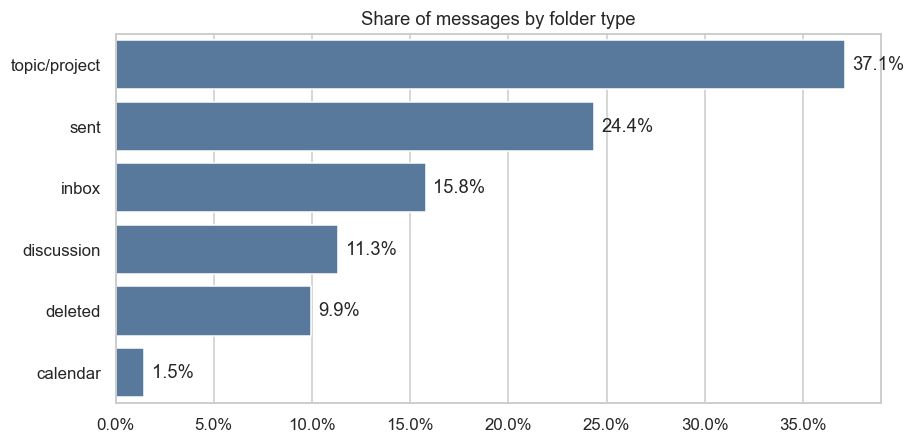

In [4]:
order = ["topic/project", "sent", "inbox", "discussion", "deleted", "calendar"]
mix = (df["folder_group"].value_counts().reindex(order) / N).reset_index()
mix.columns = ["folder_group", "share"]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
sns.barplot(mix, x="share", y="folder_group", ax=ax, color="#4c78a8")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title="Share of messages by folder type", xlabel="", ylabel="")
for i, v in enumerate(mix["share"]):
    ax.text(v + 0.004, i, f"{v:.1%}", va="center")
fig.tight_layout()
fig.savefig(PLOTS / "folder_group_mix.png", bbox_inches="tight")
plt.show()

Project and topic folders are the largest block at 37%, followed by sent mail
(24%) and inbox-style folders (16%). Deleted mail is a tenth of everything,
which is large enough to be worth a section of its own.

## What the numbers look like

Four numeric variables describe the shape of a message: how big the file is,
how many people it went to, how long the subject is, and how long the body is.
All four are heavily skewed. Most messages are small and narrowly addressed,
and a long tail of large or widely-copied messages stretches the scale. The
file-size axis below is logarithmic for that reason, and recipient and body
counts are clipped at a high percentile so the bulk stays readable.

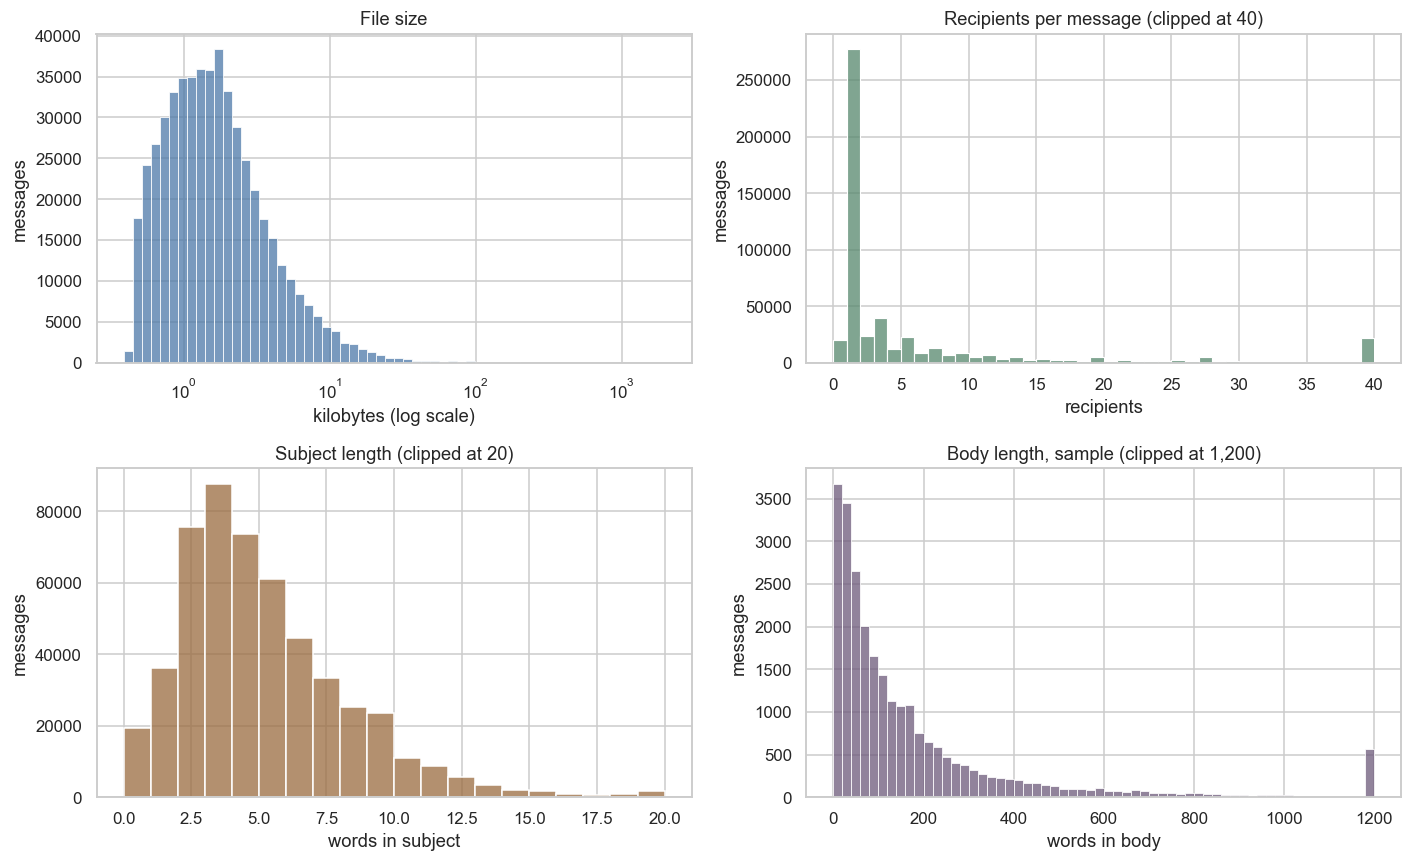

medians  | 95th percentile
  file size kb       1.5 |      7.7
  recipients         1.0 |     32.0
  subject words      4.0 |     11.0
  body words        91.0 |    697.0


In [5]:
bsamp = body.merge(df[["rel_path"]], on="rel_path", how="inner")

fig, ax = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df["file_size_kb"].clip(lower=0.1), bins=60, log_scale=True,
             ax=ax[0, 0], color="#4c78a8")
ax[0, 0].set(title="File size", xlabel="kilobytes (log scale)", ylabel="messages")

sns.histplot(df["recipient_count"].clip(upper=40), bins=40,
             ax=ax[0, 1], color="#56876d")
ax[0, 1].set(title="Recipients per message (clipped at 40)",
             xlabel="recipients", ylabel="messages")

sns.histplot(df["subject_words"].clip(upper=20), bins=20,
             ax=ax[1, 0], color="#9a6b3f")
ax[1, 0].set(title="Subject length (clipped at 20)",
             xlabel="words in subject", ylabel="messages")

sns.histplot(bsamp["body_words"].clip(upper=1200), bins=60,
             ax=ax[1, 1], color="#6d597a")
ax[1, 1].set(title="Body length, sample (clipped at 1,200)",
             xlabel="words in body", ylabel="messages")

fig.tight_layout()
fig.savefig(PLOTS / "core_distributions.png", bbox_inches="tight")
plt.show()

print("medians  | 95th percentile")
for col, s in [("file size kb", df["file_size_kb"]),
               ("recipients", df["recipient_count"]),
               ("subject words", df["subject_words"]),
               ("body words", bsamp["body_words"])]:
    print(f"  {col:<14} {s.median():7.1f} | {s.quantile(0.95):8.1f}")

The typical message is small: about 1.5 KB, one recipient, a four-word subject,
and a body under 100 words. The tails are long: the 95th percentile body is
roughly seven times the median, and recipient lists reach into the hundreds. Any later use of these variables needs a log or clipped form rather
than the raw value.

## When the mail was written

The `Date` header is parsed for every message. A few hundred files carry
nonsense dates (years like 1980 or 2044 from broken clocks), so the timeline
below is restricted to 1997-2002, which still keeps 99.9% of the corpus. The
shape follows Enron's own history: a quiet late-1990s, a steep ramp through
2000, a peak in 2001 around the California energy crisis, and a sharp fall after
the company failed at the end of 2001.

/tmp/ipykernel_449280/3000990524.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  dated["month"] = dated["date"].dt.to_period("M").dt.to_timestamp()


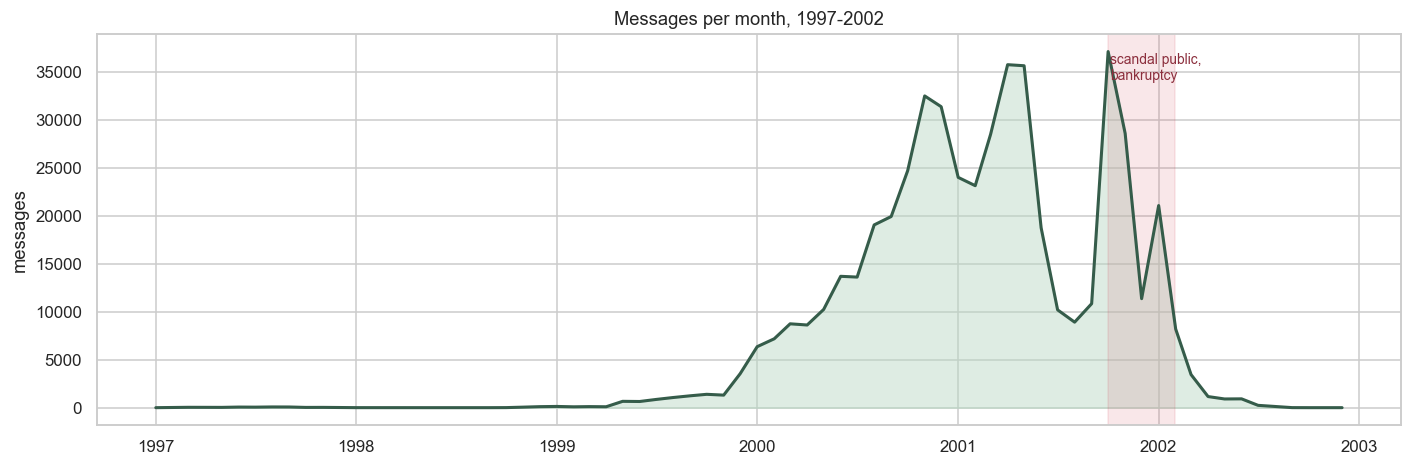

busiest month: 2001-10 with 37,139 messages
messages inside 1997-2002: 516,796 (99.9%)


In [6]:
dated = df[df["date_plausible"]].copy()
dated["month"] = dated["date"].dt.to_period("M").dt.to_timestamp()
monthly = dated.groupby("month").size()

fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(monthly.index, monthly.values, color="#355c4a", linewidth=2)
ax.fill_between(monthly.index, monthly.values, color="#b6d7c2", alpha=0.45)
ax.axvspan(pd.Timestamp("2001-10-01"), pd.Timestamp("2002-01-31"),
           color="#d1495b", alpha=0.13)
ax.text(pd.Timestamp("2001-10-05"), monthly.max() * 0.92,
        "scandal public,\nbankruptcy", color="#8c2f3d", fontsize=9)
ax.set(title="Messages per month, 1997-2002", xlabel="", ylabel="messages")
fig.tight_layout()
fig.savefig(PLOTS / "monthly_volume.png", bbox_inches="tight")
plt.show()

peak = monthly.idxmax()
print(f"busiest month: {peak:%Y-%m} with {monthly.max():,} messages")
print(f"messages inside 1997-2002: {len(dated):,} ({len(dated)/N:.1%})")

Mail volume peaks in October 2001 with about 37,000 messages, the same month
the accounting fraud became public. The shaded band marks the collapse window
(October 2001 to January 2002), which the next section returns to.

## What Enron employees threw away

Because the mailboxes were captured whole, the `Deleted Items` trash folder was
captured too. That is unusual: most email datasets only show what people kept.
Here we can also see what they discarded, which is the focus of this section.

Deletion is treated as `folder_group == "deleted"`, which is almost entirely
the standard `deleted_items` trash folder.

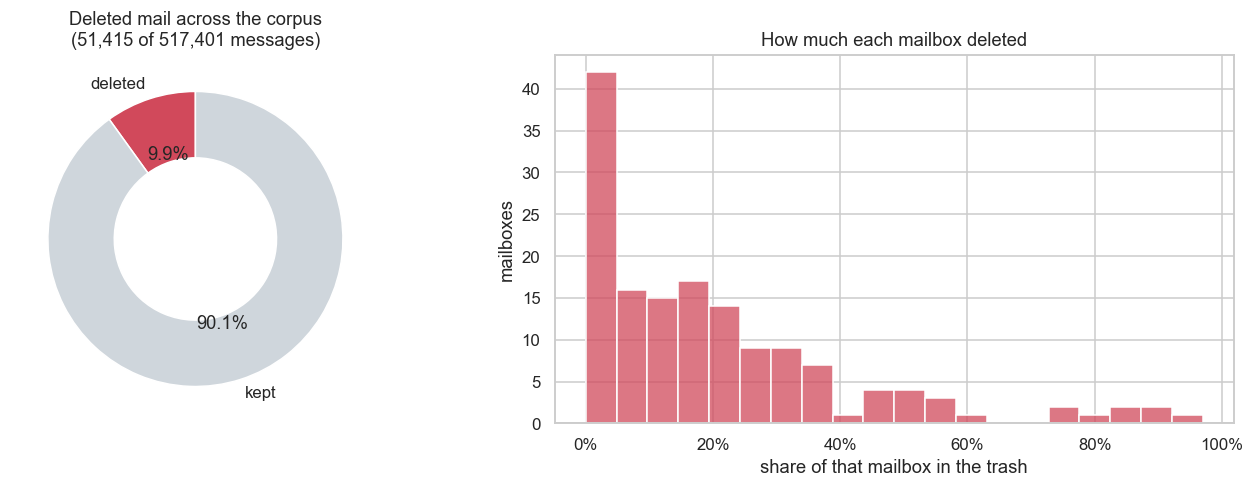

mailboxes with a non-empty trash: 135 of 150
per-mailbox deletion rate: median 15%, mean 20%
most-deleted mailboxes:
user
meyers-a    97 %
bailey-s    91 %
harris-s    90 %
panus-s     86 %
maggi-m     83 %


In [7]:
share = df["deleted"].mean()
per_user_del = (df.groupby("user")["deleted"].mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].pie([share, 1 - share], labels=["deleted", "kept"],
            autopct="%1.1f%%", colors=["#d1495b", "#cfd6dc"],
            startangle=90, wedgeprops={"width": 0.45})
axes[0].set(title=f"Deleted mail across the corpus\n"
                  f"({df['deleted'].sum():,} of {N:,} messages)")

sns.histplot(per_user_del.values, bins=20, ax=axes[1], color="#d1495b")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set(title="How much each mailbox deleted",
            xlabel="share of that mailbox in the trash",
            ylabel="mailboxes")
fig.tight_layout()
fig.savefig(PLOTS / "deleted_overview.png", bbox_inches="tight")
plt.show()

with_trash = (df.groupby("user")["deleted"].sum() > 0).sum()
print(f"mailboxes with a non-empty trash: {with_trash} of {df['user'].nunique()}")
print(f"per-mailbox deletion rate: median {per_user_del.median():.0%}, "
      f"mean {per_user_del.mean():.0%}")
print("most-deleted mailboxes:")
print((per_user_del.sort_values(ascending=False).head(5) * 100).round(0)
      .astype(int).astype(str).add(" %").to_string())

A tenth of the whole corpus (51,415 messages) sits in the trash, and 135 of the
150 mailboxes have one. But the habit is wildly uneven. The median mailbox has
about 15% of its mail deleted, while some are almost entirely trash:
`meyers-a` is 97% deleted, `maggi-m` 83%. "Deleted" is therefore a personal
habit, not a uniform label, and cannot be read as a quality signal on its own.

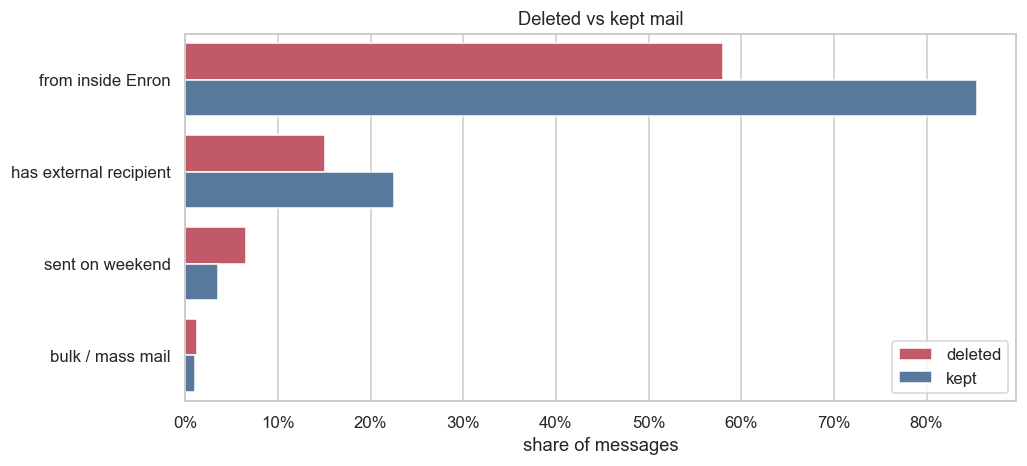

median body length, deleted: 119 words, kept: 89 words


In [8]:
flags = ["is_internal_sender", "has_external_recipient", "is_weekend",
         "is_mass_message"]
labels = ["from inside Enron", "has external recipient",
          "sent on weekend", "bulk / mass mail"]
comp = pd.DataFrame({
    "deleted": [df.loc[df["deleted"], f].mean() for f in flags],
    "kept": [df.loc[~df["deleted"], f].mean() for f in flags],
}, index=labels).reset_index().melt("index", var_name="set", value_name="rate")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
sns.barplot(comp, x="rate", y="index", hue="set", ax=ax,
            palette={"deleted": "#d1495b", "kept": "#4c78a8"})
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title="Deleted vs kept mail", xlabel="share of messages", ylabel="")
ax.legend(title="")
fig.tight_layout()
fig.savefig(PLOTS / "deleted_vs_kept.png", bbox_inches="tight")
plt.show()

bd = body.merge(df[["rel_path", "deleted"]], on="rel_path", how="inner")
print(f"median body length, deleted: "
      f"{bd.loc[bd['deleted'], 'body_words'].median():.0f} words, "
      f"kept: {bd.loc[~bd['deleted'], 'body_words'].median():.0f} words")

Deleted mail looks different from kept mail. Only 58% of it comes from an
internal enron.com address, against 85% of kept mail, so people disproportionately
trashed messages that arrived from outside. Deleted messages are also a little
more likely to land on a weekend, and their bodies are slightly longer (median
119 words against 89). The pattern fits keeping short internal working notes and
discarding longer inbound mail from outside.

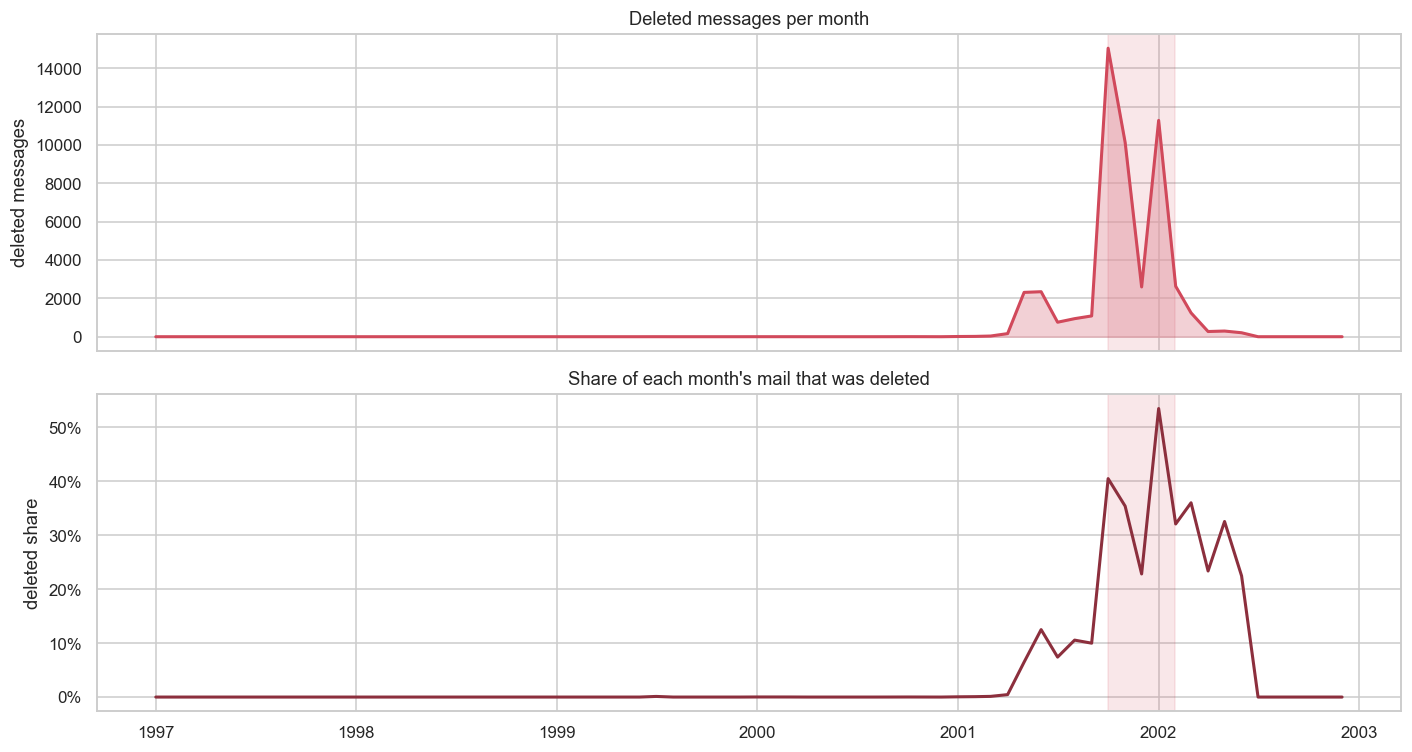

months with the most deleted mail:
month
2001-10-01    15046
2002-01-01    11281
2001-11-01    10130
2002-02-01     2633


In [9]:
md = dated.groupby(["month", "deleted"]).size().unstack(fill_value=0)
md.columns = ["kept", "deleted"]
del_share = md["deleted"] / md.sum(axis=1)

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(md.index, md["deleted"], color="#d1495b", linewidth=2)
ax[0].fill_between(md.index, md["deleted"], color="#e7a3ad", alpha=0.5)
ax[0].axvspan(pd.Timestamp("2001-10-01"), pd.Timestamp("2002-01-31"),
              color="#d1495b", alpha=0.13)
ax[0].set(title="Deleted messages per month", ylabel="deleted messages")

ax[1].plot(del_share.index, del_share.values, color="#8c2f3d", linewidth=2)
ax[1].axvspan(pd.Timestamp("2001-10-01"), pd.Timestamp("2002-01-31"),
              color="#d1495b", alpha=0.13)
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[1].set(title="Share of each month's mail that was deleted",
          xlabel="", ylabel="deleted share")
fig.tight_layout()
fig.savefig(PLOTS / "deleted_over_time.png", bbox_inches="tight")
plt.show()

top_del = md["deleted"].sort_values(ascending=False).head(4)
print("months with the most deleted mail:")
print(top_del.to_string())

This is the strongest pattern in the deleted mail. For years the trash grows
slowly, then it spikes: October 2001 alone holds about 15,000 deleted messages,
January 2002 around 11,000, November 2001 around 10,000. That window is exactly
when the fraud became public, the company filed for bankruptcy, and federal
investigators moved in. Folder placement alone cannot separate routine cleanup
from anything else, but the timing is hard to miss: the trash fills up just as
the company comes apart.

## Senders and reach

The corpus is mostly internal traffic, but it is not closed. Looking at sender
domains and how many people each message reached shows how much of the mail
crossed the company boundary.

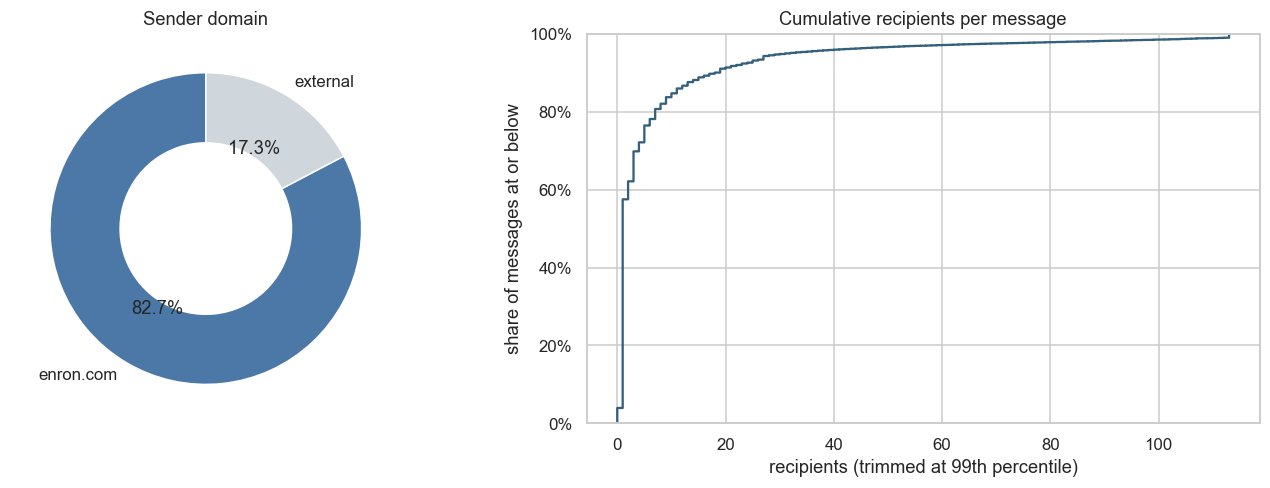

internal senders: 82.7%
messages with an external recipient: 21.7%


In [10]:
internal = df["is_internal_sender"].mean()
ext_recip = df["has_external_recipient"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].pie([internal, 1 - internal],
            labels=["enron.com", "external"], autopct="%1.1f%%",
            colors=["#4c78a8", "#cfd6dc"], startangle=90,
            wedgeprops={"width": 0.45})
axes[0].set(title="Sender domain")

sns.ecdfplot(df["recipient_count"].clip(upper=
             int(df["recipient_count"].quantile(0.99))), ax=axes[1],
             color="#34607d")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set(title="Cumulative recipients per message",
            xlabel="recipients (trimmed at 99th percentile)",
            ylabel="share of messages at or below")
fig.tight_layout()
fig.savefig(PLOTS / "senders_reach.png", bbox_inches="tight")
plt.show()

print(f"internal senders: {internal:.1%}")
print(f"messages with an external recipient: {ext_recip:.1%}")

About 83% of mail is sent from an enron.com address, and a fifth of all
messages reach at least one outside recipient. Most messages go to just one or
two people; the recipient curve climbs almost vertically at the start and then
flattens into the long bulk-mail tail seen earlier.

## A missing piece: reply threading

Email clients normally chain replies together with `In-Reply-To` and
`References` headers. This release has neither, since they were stripped before
distribution. Reconstructing conversations therefore has to fall back on
repeated subjects, which is a much weaker signal. This is a known limitation to
flag early rather than a defect in the data.

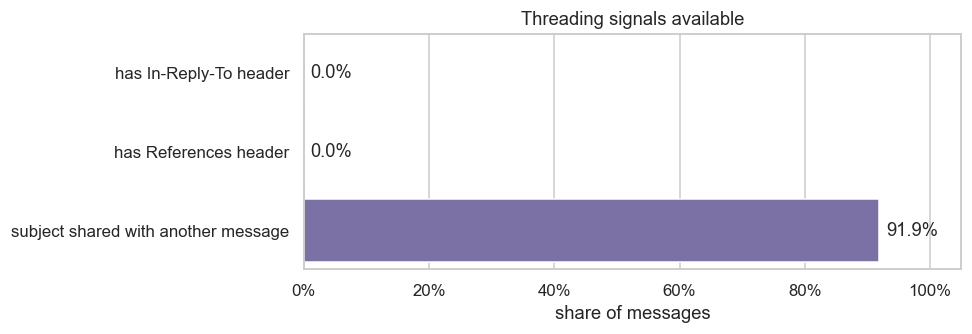

In [11]:
sn = df["subject_norm"]
signals = pd.Series({
    "has In-Reply-To header": df["has_in_reply_to"].mean(),
    "has References header": df["has_references"].mean(),
    "subject shared with another message":
        sn.map(sn.value_counts()).gt(1).mean(),
})

fig, ax = plt.subplots(figsize=(9, 3.2))
sns.barplot(x=signals.values, y=signals.index, ax=ax, color="#7768ae")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title="Threading signals available", xlabel="share of messages",
       ylabel="")
for i, v in enumerate(signals.values):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
ax.set_xlim(0, 1.05)
fig.tight_layout()
fig.savefig(PLOTS / "threading_signals.png", bbox_inches="tight")
plt.show()

No message has a reply header, while 92% share a normalised subject with at
least one other message. Subject matching will group genuine threads together
with unrelated mail that happens to share a title, so any thread reconstruction
needs sender and time checks on top of it.

## Conclusion

The corpus is 517,401 real, non-anonymised emails from 150 Enron mailboxes,
spread very unevenly across people and dominated by a few large accounts. Each
record is one RFC-822 message with its folder context preserved. The numeric
fields (file size, recipients, subject and body length) are all small in the
typical case with long right tails, so they need transforming before use. The
timeline tracks Enron's real history, peaking in October 2001.

The clearest single finding is in the deleted mail. A tenth of the corpus was
thrown away, the rate per person ranges from near zero to almost everything,
and deletion volume spikes sharply in the exact months the company collapsed
and was investigated. The main caveat carried forward is that this release has
no reply-threading headers, so conversation structure has to be reconstructed
from weaker subject and timing signals.